In [1]:
import os
import numpy as np
import pandas as pd
from tabulate import tabulate

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

import matplotlib.pyplot as plt

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


# Paths & Dataset Map

In [4]:
ROOT_DIR = "/users/"
PREPROC_DIR = os.path.join(ROOT_DIR, "preprocessed-dataset")

DATASET_PATHS = {
    "CSE-CIC-IDS2018":    os.path.join(PREPROC_DIR, "CSE_CIC_IDS2018"),
    "CIC_IIoT_2025":      os.path.join(PREPROC_DIR, "CIC_IIoT_2025"),
    "CIC_BCCC_IoMT_2024": os.path.join(PREPROC_DIR, "CIC_BCCC_NRC_IoMT_2024"),
    "Combined":           os.path.join(PREPROC_DIR, "Combined"),
}

ENERGY_DIR = os.path.join(ROOT_DIR, "Models", "EnergySim")
os.makedirs(ENERGY_DIR, exist_ok=True)

print("📂 PREPROC_DIR:", PREPROC_DIR)
print("📂 ENERGY_DIR :", ENERGY_DIR)
print("📂 DATASET_PATHS:")
for k, v in DATASET_PATHS.items():
    print(f"   - {k}: {v}")

📂 PREPROC_DIR: /users/
📂 ENERGY_DIR : /users/
📂 DATASET_PATHS:
   - CSE-CIC-IDS2018: /users/
   - CIC_IIoT_2025: /users/
   - CIC_BCCC_IoMT_2024: /users/
   - Combined: /users/


# Dataset Loader

In [5]:
def load_preprocessed_dataset(ds_name: str):
    path = DATASET_PATHS[ds_name]

    latent_files = {
        "X_train": "train_latent.npy",
        "X_val":   "val_latent.npy",
        "X_test":  "test_latent.npy",
        "y_train": "y_train.npy",
        "y_val":   "y_val.npy",
        "y_test":  "y_test.npy",
    }

    if ds_name == "Combined":
        latent_files = {
            "X_train": "combined_train_latent.npy",
            "X_val":   "combined_val_latent.npy",
            "X_test":  "combined_test_latent.npy",
            "y_train": "combined_y_train.npy",
            "y_val":   "combined_y_val.npy",
            "y_test":  "combined_y_test.npy",
        }

    X_train = np.load(os.path.join(path, latent_files["X_train"]))
    X_val   = np.load(os.path.join(path, latent_files["X_val"]))
    X_test  = np.load(os.path.join(path, latent_files["X_test"]))

    y_train = np.load(os.path.join(path, latent_files["y_train"]))
    y_val   = np.load(os.path.join(path, latent_files["y_val"]))
    y_test  = np.load(os.path.join(path, latent_files["y_test"]))

    num_classes = len(np.unique(y_train))

    print(f"""📂 Loaded dataset: {ds_name}
  Path: {path}
  X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}
  y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}
  Num classes: {num_classes}
""")

    return X_train, y_train, X_val, y_val, X_test, y_test, num_classes

# FALCON-ID Local Model (CNN + BiLSTM + Attention)

In [6]:
def build_falcon_id_local_model(
    input_dim,
    num_classes,
    learning_rate=1e-3,
    l2_reg=1e-4,
    dropout_rate=0.4,
):
    inp = layers.Input(shape=(input_dim,), name="latent_input")
    x = layers.Reshape((input_dim, 1))(inp)  # (batch, 64, 1) for 64-dim latent

    # ---- Residual Block 1 ----
    shortcut = layers.Conv1D(
        64, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    x1 = layers.Conv1D(
        64, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation("relu")(x1)
    x1 = layers.Conv1D(
        64, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x1)
    x1 = layers.BatchNormalization()(x1)

    x = layers.Add()([shortcut, x1])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ---- Residual Block 2 ----
    shortcut2 = layers.Conv1D(
        128, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    x2 = layers.Conv1D(
        128, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation("relu")(x2)
    x2 = layers.Conv1D(
        128, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x2)
    x2 = layers.BatchNormalization()(x2)

    x = layers.Add()([shortcut2, x2])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.SpatialDropout1D(0.2)(x)

    # ---- BiLSTM ----
    x = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(l2_reg),
        )
    )(x)

    # ---- Additive-like Attention ----
    score = layers.Dense(128, activation="tanh")(x)
    attn_weights = layers.Dense(1, activation="softmax")(score)
    context = layers.Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))(
        [x, attn_weights]
    )

    # ---- Classifier ----
    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(context)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(
        128, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(num_classes, activation="softmax", name="logits")(x)

    model = models.Model(
        inputs=inp,
        outputs=out,
        name="FALCON_ID_CNN_BiLSTM_Attn"
    )

    # Compile (not actually used for training in this notebook)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model

In [7]:
tmp_X, tmp_y, *_ = load_preprocessed_dataset("CIC_IIoT_2025")
tmp_model = build_falcon_id_local_model(input_dim=tmp_X.shape[1],
                                        num_classes=len(np.unique(tmp_y)))
print("🧱 FALCON-ID Params:", tmp_model.count_params())
del tmp_X, tmp_y, tmp_model

📂 Loaded dataset: CIC_IIoT_2025
  Path: /users/
  X_train: (29424, 64), X_val: (6305, 64), X_test: (6306, 64)
  y_train: (29424,), y_val: (6305,), y_test: (6306,)
  Num classes: 7

🧱 FALCON-ID Params: 493896


# Federated Client Partition (same as previous notebooks)

In [8]:
def make_federated_clients(
    X_train: np.ndarray,
    y_train: np.ndarray,
    num_clients: int = 10,
    shuffle: bool = True,
):
    n_samples = len(X_train)
    indices = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(SEED)
        rng.shuffle(indices)

    X_train = X_train[indices]
    y_train = y_train[indices]

    base_size = n_samples // num_clients
    remainder = n_samples % num_clients

    client_splits = []
    start = 0
    for i in range(num_clients):
        size = base_size + (1 if i < remainder else 0)
        end = start + size
        X_c = X_train[start:end]
        y_c = y_train[start:end]
        client_splits.append((X_c, y_c))
        print(f"  -> Client {i}: {len(X_c)} samples")
        start = end

    return client_splits

# Energy Model Definitions

In [9]:
ENERGY_PER_FLOP = 1e-9
ENERGY_PER_BYTE_COMM = 5e-10

LOCAL_SAMPLE_CAP = 10_000
ROUNDS = 5
NUM_CLIENTS = 10

In [10]:
EDGE_PROFILES = {
    "LOW":  {"battery": 120.0, "compute_coef": 1.3, "comm_coef": 1.3},
    "MID":  {"battery": 160.0, "compute_coef": 1.0, "comm_coef": 1.0},
    "HIGH": {"battery": 220.0, "compute_coef": 0.8, "comm_coef": 0.8},
}

In [11]:
def estimate_flops_per_sample(model: tf.keras.Model) -> float:
    num_params = model.count_params()
    flops_per_sample = 4.0 * num_params
    return flops_per_sample

In [12]:
def estimate_model_comm_bytes(model: tf.keras.Model) -> int:
    total_params = model.count_params()
    single_direction = total_params * 4  # bytes
    bidirectional = 2 * single_direction
    return int(bidirectional)

# Energy-Aware FL Simulation

In [13]:
def run_energy_aware_fl(
    ds_name: str,
    rounds: int = ROUNDS,
    num_clients: int = NUM_CLIENTS,
) -> pd.DataFrame:
    print("\n" + "#" * 80)
    print(f"### 🔋 Energy-Aware FL Simulation — Dataset: {ds_name}")
    print("#" * 80)

    # 1) Load dataset (only shapes used)
    X_train, y_train, X_val, y_val, X_test, y_test, num_classes = load_preprocessed_dataset(ds_name)
    input_dim = X_train.shape[1]
    total_train_samples = len(X_train)

    # 2) Federated client splits (like earlier notebooks)
    print(f"👥 Creating {num_clients} federated clients for {ds_name}...")
    client_splits = make_federated_clients(X_train, y_train, num_clients=num_clients)

    # 3) Build base model for FLOPs + comm estimation
    print(f"\n🧱 Building FALCON-ID model for energy estimation ({ds_name})...")
    base_model = build_falcon_id_local_model(input_dim=input_dim,
                                             num_classes=num_classes)
    flops_per_sample = estimate_flops_per_sample(base_model)
    comm_bytes_model = estimate_model_comm_bytes(base_model)

    print(f"   → Model params: {base_model.count_params():,}")
    print(f"   → Approx FLOPs/sample (fwd+backward): {flops_per_sample:,.2f}")
    print(f"   → Approx comm bytes per round (uplink+downlink): {comm_bytes_model/1e6:.3f} MB")

    # 4) Assign heterogeneous edge profiles to clients
    rng = np.random.default_rng(SEED)
    edge_types = rng.choice(list(EDGE_PROFILES.keys()), size=num_clients)

    client_profiles = []
    for cid in range(num_clients):
        etype = edge_types[cid]
        prof = EDGE_PROFILES[etype]
        client_profiles.append({
            "client_id": cid,
            "edge_type": etype,
            "energy": prof["battery"],
            "compute_coef": prof["compute_coef"],
            "comm_coef": prof["comm_coef"],
            "n_samples_total": len(client_splits[cid][0]),
        })

    print("\n📡 Edge profiles per client:")
    for cp in client_profiles:
        print(f"   Client {cp['client_id']:2d} | type={cp['edge_type']:<4} | "
              f"battery={cp['energy']:.1f} | n_samples={cp['n_samples_total']}")

    # 5) Simulate rounds
    detailed_rows = []
    active_clients = list(range(num_clients))

    for r in range(1, rounds + 1):
        if len(active_clients) == 0:
            print(f"\n⚠️ All clients dead before round {r}. Stopping early.")
            break

        print(f"\n===== 🔁 Energy-Aware Round {r}/{rounds} — Dataset: {ds_name} =====")
        round_energy_used = 0.0

        for cid in active_clients:
            cp = client_profiles[cid]
            if cp["energy"] <= 0:
                continue

            n_local = cp["n_samples_total"]
            if n_local == 0:
                continue

            num_samples_used = min(LOCAL_SAMPLE_CAP, n_local)

            # Compute approximate FLOPs and energy for compute
            flops_local = flops_per_sample * num_samples_used
            energy_compute = flops_local * ENERGY_PER_FLOP * cp["compute_coef"]

            # Communication energy (model upload + download)
            energy_comm = comm_bytes_model * ENERGY_PER_BYTE_COMM * cp["comm_coef"]

            energy_used = energy_compute + energy_comm
            energy_before = cp["energy"]
            cp["energy"] = max(0.0, cp["energy"] - energy_used)
            alive_after = cp["energy"] > 0

            round_energy_used += energy_used

            detailed_rows.append({
                "dataset": ds_name,
                "round": r,
                "client_id": cid,
                "edge_type": cp["edge_type"],
                "n_samples_total": n_local,
                "num_samples_used": num_samples_used,
                "flops_local": flops_local,
                "comm_bytes_model": comm_bytes_model,
                "energy_before": energy_before,
                "energy_after": cp["energy"],
                "energy_compute": energy_compute,
                "energy_comm": energy_comm,
                "energy_used_total": energy_used,
                "alive_after": int(alive_after),
            })

            print(f"   Client {cid:2d} ({cp['edge_type']}) | "
                  f"samples_used={num_samples_used:6d} | "
                  f"E_before={energy_before:7.3f} → E_after={cp['energy']:7.3f} | "
                  f"alive={alive_after}")

        # Update active client list
        active_clients = [
            cid for cid in active_clients
            if client_profiles[cid]["energy"] > 0
        ]

        alive_count = len(active_clients)
        avg_energy = np.mean([cp["energy"] for cp in client_profiles])
        print(f"   → Round {r} summary: total_energy_used={round_energy_used:.3f}, "
              f"active_clients={alive_count}/{num_clients}, "
              f"avg_client_energy={avg_energy:.3f}")

    detailed_df = pd.DataFrame(detailed_rows)

    # 6) Save per-dataset detailed log + round summary
    detail_path = os.path.join(ENERGY_DIR, f"{ds_name}_energy_log.csv")
    detailed_df.to_csv(detail_path, index=False)
    print(f"\n💾 Saved detailed energy log for {ds_name} → {detail_path}")

    # Round summary
    if not detailed_df.empty:
        round_summary = (
            detailed_df
            .groupby(["dataset", "round"], as_index=False)
            .agg(
                total_energy_used=("energy_used_total", "sum"),
                avg_energy_after=("energy_after", "mean"),
                active_clients=("alive_after", "sum"),
                avg_comm_bytes=("comm_bytes_model", "mean"),
            )
        )
    else:
        round_summary = pd.DataFrame(columns=[
            "dataset", "round", "total_energy_used", "avg_energy_after",
            "active_clients", "avg_comm_bytes"
        ])

    round_path = os.path.join(ENERGY_DIR, f"{ds_name}_energy_round_summary.csv")
    round_summary.to_csv(round_path, index=False)
    print(f"💾 Saved round-level energy summary for {ds_name} → {round_path}")

    return detailed_df, round_summary

# Run Energy Simulation on All Datasets

In [14]:
all_detailed = []
all_round_summaries = []
global_summary_rows = []

for ds_name in DATASET_PATHS.keys():
    detailed_df, round_summary = run_energy_aware_fl(
        ds_name,
        rounds=ROUNDS,
        num_clients=NUM_CLIENTS,
    )
    all_detailed.append(detailed_df)
    all_round_summaries.append(round_summary)

    if detailed_df.empty:
        continue

    # Dataset-level aggregate summary
    total_energy = detailed_df["energy_used_total"].sum()
    max_round = int(detailed_df["round"].max())
    final_alive = int(
        detailed_df[detailed_df["round"] == max_round]["alive_after"].sum()
    )
    avg_comm_bytes = detailed_df["comm_bytes_model"].mean()
    total_comm_bytes = avg_comm_bytes * NUM_CLIENTS * max_round

    global_summary_rows.append({
        "dataset": ds_name,
        "rounds_simulated": max_round,
        "total_energy_used": total_energy,
        "avg_energy_per_round": total_energy / max_round,
        "final_active_clients": final_alive,
        "avg_comm_bytes_per_round": avg_comm_bytes * NUM_CLIENTS,
        "total_comm_bytes": total_comm_bytes,
    })


################################################################################
### 🔋 Energy-Aware FL Simulation — Dataset: CSE-CIC-IDS2018
################################################################################
📂 Loaded dataset: CSE-CIC-IDS2018
  Path: /users/
  X_train: (6737603, 64), X_val: (1443772, 64), X_test: (1443773, 64)
  y_train: (6737603,), y_val: (1443772,), y_test: (1443773,)
  Num classes: 15

👥 Creating 10 federated clients for CSE-CIC-IDS2018...
  -> Client 0: 673761 samples
  -> Client 1: 673761 samples
  -> Client 2: 673761 samples
  -> Client 3: 673760 samples
  -> Client 4: 673760 samples
  -> Client 5: 673760 samples
  -> Client 6: 673760 samples
  -> Client 7: 673760 samples
  -> Client 8: 673760 samples
  -> Client 9: 673760 samples

🧱 Building FALCON-ID model for energy estimation (CSE-CIC-IDS2018)...
   → Model params: 494,928
   → Approx FLOPs/sample (fwd+backward): 1,979,712.00
   → Approx comm bytes per round (uplink+downlink): 3.959 MB

📡 Edge p

# Global Energy Summary Across Datasets

In [15]:
if len(global_summary_rows) > 0:
    global_summary_df = pd.DataFrame(global_summary_rows)
    summary_path = os.path.join(ENERGY_DIR, "energy_summary_all_datasets.csv")
    global_summary_df.to_csv(summary_path, index=False)
    print(f"\n📊 Global energy summary saved at: {summary_path}\n")

    print("============= 🌍 Energy-Aware FL Summary Across Datasets =============")
    print(tabulate(
        global_summary_df,
        headers="keys",
        tablefmt="github",
        floatfmt=".4f",
    ))
else:
    print("\n⚠️ No energy logs generated (check earlier errors).")


📊 Global energy summary saved at: /users/

============= 🌍 Energy-Aware FL Summary Across Datasets =============
|    | dataset            |   rounds_simulated |   total_energy_used |   avg_energy_per_round |   final_active_clients |   avg_comm_bytes_per_round |   total_comm_bytes |
|----|--------------------|--------------------|---------------------|------------------------|------------------------|----------------------------|--------------------|
|  0 | CSE-CIC-IDS2018    |                  5 |           1049.3523 |               209.8705 |                      6 |              39594240.0000 |     197971200.0000 |
|  1 | CIC_IIoT_2025      |                  5 |            308.1901 |                61.6380 |                     10 |              39511680.0000 |     197558400.0000 |
|  2 | CIC_BCCC_IoMT_2024 |                  5 |           1049.3523 |               209.8705 |                      6 |              39594240.0000 |     197971200.0000 |
|  3 | Combined           |    

# Quick Visualization Helper

In [16]:
def plot_energy_rounds(round_summary_df, ds_name: str):
    if round_summary_df is None or round_summary_df.empty:
        print(f"⚠️ No round summary to plot for {ds_name}")
        return

    sub = round_summary_df[round_summary_df["dataset"] == ds_name]

    plt.figure(figsize=(8, 5))
    plt.plot(sub["round"], sub["avg_energy_after"], marker="o")
    plt.xlabel("Round")
    plt.ylabel("Average Client Energy (units)")
    plt.title(f"Energy Decay over Rounds — {ds_name}")
    plt.grid(True)
    plt.show()

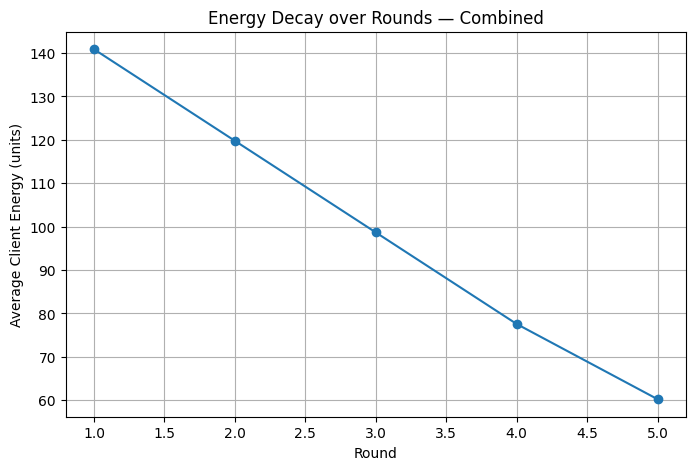

In [17]:
if len(all_round_summaries) > 0:
    combined_round_summary = pd.concat(all_round_summaries, ignore_index=True)
    plot_energy_rounds(combined_round_summary, "Combined")